## **Exploratory Data Analysis (EDA) E-Commerce Sales & Profit Analysis**:


Pada Dataset ini terdiri dari 3.500 pesanan e-commerce dengan 7 fitur utama. Data ini mencakup transaksi penjualan di berbagai produk, kategori, dan wilayah, beserta detail kuantitas, pendapatan, dan keuntungan.

Data ini lengkap, tidak mengandung nilai yang hilang, dan mencerminkan pola bisnis realistis yang cocok untuk tugas analitis dan prediktif.



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
path = "/content/drive/MyDrive/AVD baru/dataset avd uts sales.csv"
df = pd.read_csv(path)
df

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28
...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02
3498,2022-01-18,Printer,Office,South,3,222,50.28


Penjelasan: Dimulai dengan menginput dataset nya menggunakan library untuk menganalisis isi data tersebut dengan memuat file sales ini.

##**INFORMASI DATA**

In [13]:
# Informasi kolom dan tipe data
df.info()

# Lihat nama kolom
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


Index(['Order Date', 'Product Name', 'Category', 'Region', 'Quantity', 'Sales',
       'Profit'],
      dtype='object')

Menampilkan kolom untuk melihat tipe data nya apa aja

#**MISSING VALUES**

In [14]:
# 1. Cek Nilai yang Kosong (Missing Values)
print("--- Jumlah Nilai Kosong per Kolom ---")
print(df.isnull().sum())

# 2. Cek Data Duplikat (Baris yang kembar identik)
print("\n--- Jumlah Baris Duplikat ---")
print(df.duplicated().sum())

--- Jumlah Nilai Kosong per Kolom ---
Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

--- Jumlah Baris Duplikat ---
0


Penjelasan: Melakukan pengecekan data kotor. Hasil menunjukkan bahwa dataset bersih karena tidak memiliki nilai yang kosong (0 missing values) dan tidak memiliki baris data yang ganda (0 duplicate rows)

# **DESKRIPTIF**

In [15]:
df.describe(include="all")

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
count,3500,3500,3500,3500,3500.000000,3500.000000,3500.000000
unique,1051,10,3,4,NaN,NaN,NaN
top,2023-08-12,Monitor,Electronics,West,NaN,NaN,NaN
freq,11,364,1742,898,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,4.931714,3047.966000,527.047203
std,NaN,NaN,NaN,NaN,2.575895,2440.213237,504.139732
min,NaN,NaN,NaN,NaN,1.000000,51.000000,6.970000
25%,NaN,NaN,NaN,NaN,3.000000,1049.500000,158.695000
50%,NaN,NaN,NaN,NaN,5.000000,2350.500000,361.070000
75%,NaN,NaN,NaN,NaN,7.000000,4537.000000,729.125000


Disini menjelaskan tentang kekuatan dan arah hubungan antara kolom-kolom angka di dalam dataset ini. Agar menampilkan dalam dunia bisnis dan data analis  kita tidak bisa hanya melihat dengan data satu persatu secara terpisah dan harus diketahui apakah ada pola yang saling ketergantungan antar variabel numerik tersebut. Maka dari itu korelasi ini di tampilkan untuk pengambilan keputusan bisnis, dan untuk seleksi fitur. Lalu menampilkan ringkasan karakteristik dasar dan rangkuman statistik dari seluruh kolom, baik yang berisi kategorikal maupun angka.

## **Bar Chart**

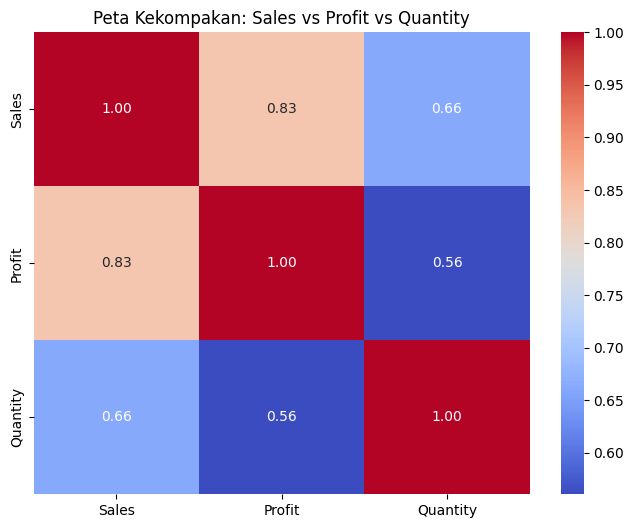

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pilih kolom yang isinya angka saja (Sales, Profit, Quantity)
# Karena korelasi hanya bisa dihitung untuk angka
kolom_angka = df[['Sales', 'Profit', 'Quantity']]

# 2. Buat tabel korelasinya
korelasi = kolom_angka.corr()

# 3. Gambar Peta Panasnya
plt.figure(figsize=(8, 6))
sns.heatmap(data=korelasi,
            annot=True,     # Menampilkan angka di dalam kotak
            cmap='coolwarm', # Warna biru-merah (jangan tulis 'warna' ya, nanti error)
            fmt='.2f')      # Menampilkan 2 angka di belakang koma

plt.title('Peta Kekompakan: Sales vs Profit vs Quantity')
plt.show()

Dari Bar chart ini menjelaskan urutan bar tertinggi ke terendah adalah Electronics, lalu Accessories, dan paling kecil Office. Ini sinkron dengan angka asli di dataset:

Electronics: 5.326.074 (Bar paling tinggi, melewati angka 5 juta)

Accessories: 4.247.591 (Bar kedua, di angka 4 jutaan)

Office: 1.094.216 (Bar terendah, sedikit di atas 1 juta)

## **Pie Chart**

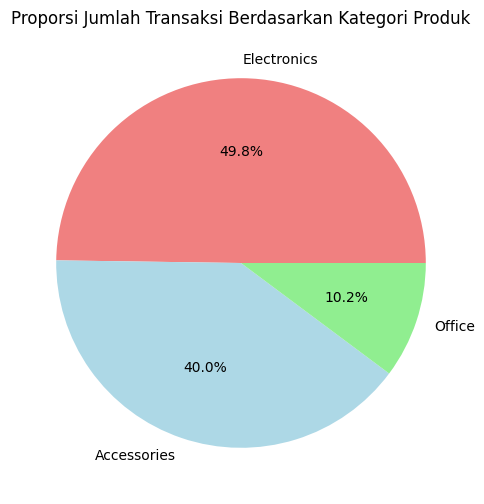

In [17]:
plt.figure(figsize=(10, 6)) # ukuran
plt.pie(df['Category'].value_counts(), labels=df['Category'].value_counts().index, autopct='%1.1f%%', colors=['lightcoral', 'lightblue', 'lightgreen', 'gold']) # colors (warna)
plt.title('Proporsi Jumlah Transaksi Berdasarkan Kategori Produk') # Judul
plt.show()

Grafik Pie Chart ini digunakan untuk melihat kontribusi atau proporsi persentase jumlah transaksi dari setiap kategori produk. Terlihat bahwa kategori Electronics mendominasi hampir setengah dari total transaksi (49.8%).

## **Scatter Plot**

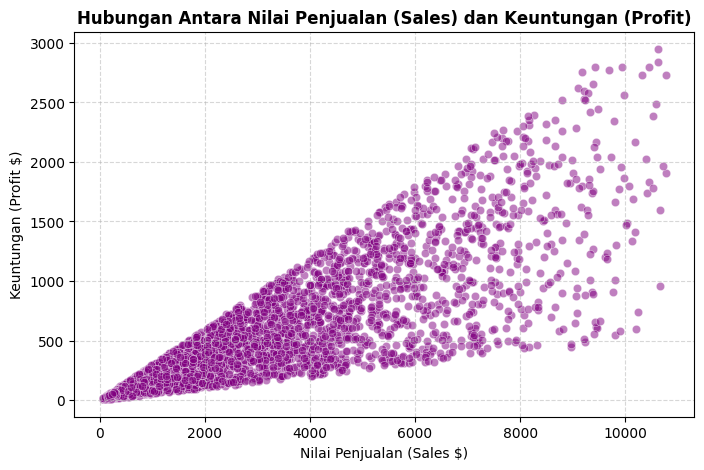

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
# Membuat scatter plot dengan warna transparan (alpha) agar tumpukan data kelihatan
sns.scatterplot(data=df, x='Sales', y='Profit', alpha=0.5, color='purple')

# Menambahkan identitas grafik agar informatif
plt.title('Hubungan Antara Nilai Penjualan (Sales) dan Keuntungan (Profit)', fontsize=12, fontweight='bold')
plt.xlabel('Nilai Penjualan (Sales $)', fontsize=10)
plt.ylabel('Keuntungan (Profit $)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Scatter Plot ini membuktikan secara visual hubungan antara Sales dan Profit. Pola titik data yang membentuk arah diagonal naik ke kanan atas menunjukkan adanya korelasi positif yang sangat kuat, di mana peningkatan nilai Sales akan selalu diikuti oleh peningkatan Profit secara konsisten

## **Line Chart**

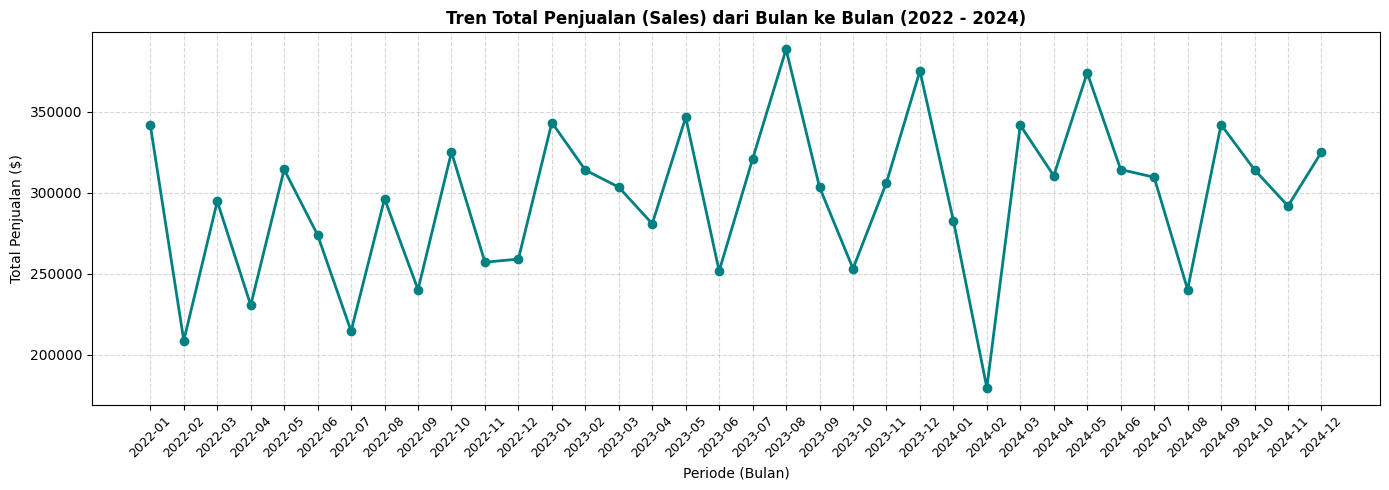

In [19]:
# Mengubah kolom tanggal menjadi tipe datetime agar bisa dibaca rentang waktunya
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Membuat kelompok Tahun-Bulan
df['Year-Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Year-Month')['Sales'].sum().reset_index()
monthly_sales['Year-Month'] = monthly_sales['Year-Month'].astype(str)

# Plotting Tren Bulanan yang Rapi
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Year-Month'], monthly_sales['Sales'], marker='o', color='teal', linewidth=2)
plt.xticks(rotation=45, fontsize=9)
plt.title('Tren Total Penjualan (Sales) dari Bulan ke Bulan (2022 - 2024)', fontsize=12, fontweight='bold')
plt.xlabel('Periode (Bulan)', fontsize=10)
plt.ylabel('Total Penjualan ($)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

line chart ini menjelaskan faktor waktu terhadap performa bisnis e-commerce. Grafik Line Chart bulanan ini wajib ditampilkan karena data bisnis itu sifatnya dinamis dan dipengaruhi oleh waktu.

#**MENYIMPAN DATA**

In [20]:
df.to_csv('/content/drive/MyDrive/AVD baru/dataset avd uts sales.csv')